<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-09-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-100.

Características do dataset:

- 60.000 imagens RGB
- 100 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar100

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import mlflow

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

SUBSET_TRAIN = 10000
SUBSET_TEST = 5000
MAX_ITER = 100
VAL_SIZE = 0.2

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("cifar100-mlp")

print("Ambiente configurado.")
print("MLflow tracking URI:", mlflow.get_tracking_uri())


2026/05/26 18:44:32 INFO mlflow.tracking.fluent: Experiment with name 'cifar100-mlp' does not exist. Creating a new experiment.


Ambiente configurado.
MLflow tracking URI: file:./mlruns


# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-100 utilizando `tensorflow.keras.datasets.cifar100.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solução**:

In [2]:
from tensorflow.keras.datasets import cifar100

def load_data(seed):
    (X_full, y_full), (_, _) = cifar100.load_data()

    X_full = X_full.reshape(X_full.shape[0], -1).astype("float32")

    X_full = X_full / 255.0

    y_full = y_full.ravel()

    if SUBSET_TRAIN is not None and SUBSET_TRAIN < len(X_full):
        X_full, _, y_full, _ = train_test_split(
            X_full, y_full,
            train_size=SUBSET_TRAIN,
            stratify=y_full,
            random_state=seed,
        )

    X_train, X_val, y_train, y_val = train_test_split(
        X_full, y_full,
        test_size=VAL_SIZE,
        stratify=y_full,
        random_state=seed,
    )

    return X_train, X_val, y_train, y_val

def load_test(seed):
    (_, _), (X_test, y_test) = cifar100.load_data()
    X_test = X_test.reshape(X_test.shape[0], -1).astype("float32") / 255.0
    y_test = y_test.ravel()
    if SUBSET_TEST is not None and SUBSET_TEST < len(X_test):
        X_test, _, y_test, _ = train_test_split(
            X_test, y_test,
            train_size=SUBSET_TEST,
            stratify=y_test,
            random_state=seed,
        )
    return X_test, y_test

X_train, X_val, y_train, y_val = load_data(SEED)
X_test, y_test = load_test(SEED)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("Features por imagem:", X_train.shape[1])
print("Min/Max apos normalizacao:", X_train.min(), X_train.max())
print("Numero de classes:", len(np.unique(y_train)))


X_train: (8000, 3072)
X_val:   (2000, 3072)
X_test:  (5000, 3072)
Features por imagem: 3072
Min/Max apos normalizacao: 0.0 1.0
Numero de classes: 100


### Respostas teoricas - Questao 1

**1. Qual o formato original das imagens?**
Cada imagem do CIFAR-100 tem formato `32 x 32 x 3`, ou seja, 32x32 pixels em 3 canais
de cor (RGB). O tensor de treino completo tem formato `(50000, 32, 32, 3)`.

**2. Quantas features cada imagem possui apos o flatten?**
`32 x 32 x 3 = 3072` features. Cada imagem vira um vetor de 3072 valores.

**3. Por que o flatten e necessario para uma MLP?**
Uma MLP (camadas totalmente conectadas) espera como entrada um **vetor 1D** de tamanho
fixo, pois cada neuronio da primeira camada se conecta a *todas* as features de entrada.
Ela nao possui a estrutura espacial 2D que uma CNN explora; portanto a imagem precisa ser
"achatada" de `(32, 32, 3)` para `(3072,)`. O custo disso e a perda da informacao de
vizinhanca espacial entre os pixels.

**4. Qual a importancia da normalizacao para o treinamento?**
Os pixels variam de 0 a 255. Dividindo por 255 colocamos as features em `[0, 1]`,
o que: (a) mantem os valores em uma escala homogenea, evitando que features de maior
magnitude dominem; (b) deixa os gradientes em uma faixa estavel, acelerando e estabilizando
a convergencia do gradiente descendente; (c) evita saturacao precoce de ativacoes como
`sigmoid`/`tanh`. Sem normalizacao o treino fica lento e instavel.


# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solução**:

In [3]:
def train_mlp(X_train, y_train, activation, hidden_layers, learning_rate, seed):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver="adam",
        learning_rate_init=learning_rate,
        max_iter=MAX_ITER,
        random_state=seed,
    )
    model.fit(X_train, y_train)
    return model

demo = train_mlp(X_train, y_train, "relu", (128, 64), 0.001, SEED)

n_input = X_train.shape[1]
n_first_hidden = 128
params_primeira = n_input * n_first_hidden + n_first_hidden
print("Modelo treinado. Iteracoes:", demo.n_iter_, "| loss final:", round(demo.loss_, 4))
print("Parametros da primeira camada:", params_primeira)


Modelo treinado. Iteracoes: 100 | loss final: 2.5714
Parametros da primeira camada: 393344


### Respostas teoricas - Questao 2

**1. Quantos parametros existem na primeira camada?**
A primeira camada conecta as `3072` features de entrada aos neuronios da primeira camada
oculta. Para a arquitetura usada na demonstracao, com `128` neuronios:
`3072 x 128 (pesos) + 128 (bias) = 393.344 parametros` apenas na primeira camada.
De forma geral: `n_features x n_neuronios + n_neuronios`.

**2. Qual a funcao da ativacao ReLU?**
ReLU (`f(x) = max(0, x)`) introduz **nao-linearidade**, permitindo que a rede aprenda
relacoes complexas (sem ela, varias camadas lineares colapsariam em uma unica
transformacao linear). E barata de calcular e, por ter derivada 1 para `x > 0`, **mitiga
o problema de vanishing gradient**, favorecendo a convergencia em redes profundas.

**3. Por que MLPs possuem muitos parametros ao trabalhar com imagens?**
Por serem **totalmente conectadas**: cada neuronio se liga a *todos* os pixels de entrada.
Com 3072 features, uma unica camada de 128 neuronios ja gera ~393 mil pesos. Como nao ha
compartilhamento de pesos (ao contrario das CNNs, que reutilizam filtros), o numero de
parametros explode com o tamanho da imagem, encarecendo o treino e aumentando o risco de
overfitting.


# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solução**:

In [4]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }
    return metrics

baseline_metrics = evaluate(demo, X_test, y_test)
df_baseline = pd.DataFrame([baseline_metrics], index=["baseline (relu, (128,64), lr=0.001)"])
print(df_baseline.round(4).to_string())


                                     accuracy  precision  recall  f1_score
baseline (relu, (128,64), lr=0.001)     0.156     0.1463   0.156     0.146


### Respostas teoricas - Questao 3

**Interpretacao:** num problema com 100 classes, o acerto puramente aleatorio seria de
apenas `1% (0.01)`. O modelo de referencia (ReLU, (128,64), lr=0.001) atingiu
**accuracy ~= 0.156 (15,6%)** e f1 ~= 0.146 - ou seja, cerca de **15x melhor que o acaso**,
mostrando que a MLP aprendeu padroes uteis. Precision e recall ficam proximos da accuracy
porque o conjunto e aproximadamente balanceado. Os valores absolutos sao modestos porque
a MLP achata a imagem e perde a estrutura espacial - o foco aqui e comparar comportamentos,
nao maximizar accuracy.

**1. O que a accuracy representa?**
A proporcao de previsoes corretas sobre o total de exemplos:
`(VP + VN) / total`. E uma visao global, mas pode enganar em datasets desbalanceados.

**2. Qual a diferenca entre precision e recall?**
- **Precision** = `VP / (VP + FP)`: das amostras que o modelo previu como uma classe,
  quantas estavam corretas. Penaliza **falsos positivos**.
- **Recall** = `VP / (VP + FN)`: das amostras que realmente pertencem a classe, quantas
  o modelo encontrou. Penaliza **falsos negativos**.

**3. Em quais situacoes o f1-score e importante?**
O f1-score e a media harmonica entre precision e recall. E importante quando ha
**desequilibrio entre classes** ou quando falsos positivos e falsos negativos tem custos
relevantes, oferecendo um unico numero que equilibra os dois (so e alto quando ambos sao
altos). Por isso e mais informativo que a accuracy em cenarios desbalanceados.


# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solução**:

In [5]:
RESULTS = []

def run_experiment(run_name, activation, hidden_layers, learning_rate,
                   batch_size="auto"):
    with mlflow.start_run(run_name=run_name):
        model = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation=activation,
            solver="adam",
            learning_rate_init=learning_rate,
            max_iter=MAX_ITER,
            batch_size=batch_size,
            random_state=SEED,
        )
        start = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start

        metrics = evaluate(model, X_test, y_test)

        params = {
            "activation": activation,
            "hidden_layers": str(hidden_layers),
            "learning_rate": learning_rate,
            "max_iter": MAX_ITER,
            "batch_size": batch_size,
        }
        for k, v in params.items():
            mlflow.log_param(k, v)
        for k, v in metrics.items():
            mlflow.log_metric(k, v)
        mlflow.log_metric("training_time", training_time)
        mlflow.log_metric("final_loss", model.loss_)
        mlflow.log_metric("n_iter", model.n_iter_)

    record = {"run_name": run_name, **params, **metrics,
              "training_time": training_time,
              "final_loss": model.loss_, "n_iter": model.n_iter_}
    RESULTS.append(record)
    print(f"[{run_name}] acc={metrics['accuracy']:.4f} "
          f"f1={metrics['f1_score']:.4f} "
          f"loss={model.loss_:.4f} tempo={training_time:.1f}s")
    return model, record

baseline_model, _ = run_experiment(
    run_name="baseline",
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
)

print("\nPara abrir a interface, execute no terminal:  mlflow ui")


[baseline] acc=0.1560 f1=0.1460 loss=2.5714 tempo=57.4s

Para abrir a interface, execute no terminal:  mlflow ui


### Respostas teoricas - Questao 4

> Todos os runs (Questoes 4-7) ficam registrados no mesmo experimento `cifar100-mlp`.
> O resumo consolidado e impresso na **Questao 8**. As respostas abaixo refletem os
> **resultados reais** obtidos nesta execucao.

**1. Qual experimento apresentou melhor desempenho?**
A configuracao **ReLU + arquitetura (128, 64) + learning_rate = 0.001** (o `baseline`, que
se repete em alguns runs) foi a melhor: **accuracy ~= 0.156 e f1 ~= 0.146**. Foi o maior
valor entre todos os 11 experimentos registrados.

**2. Qual configuracao apresentou maior estabilidade?**
As configuracoes com **learning_rate = 0.001** foram as unicas estaveis: a loss caiu de
forma suave ate ~2.57. Ja `learning_rate = 0.01` e `0.1` ficaram **presos em accuracy de
acaso (~0.01) com loss ~= ln(100) ~= 4.6**, ou seja, a rede nao aprendeu - evidencia de
instabilidade causada por taxa de aprendizado alta demais.

**3. Qual o beneficio do rastreamento experimental?**
O MLflow garante **reprodutibilidade e organizacao**: registra parametros, metricas e tempo
de cada run, permitindo comparar dezenas de experimentos lado a lado, recuperar a melhor
configuracao, evitar retrabalho e documentar decisoes. Sem isso, comparar hiperparametros
vira um processo manual e propenso a erros.


# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solução**:

[activation_logistic] acc=0.1386 f1=0.1247 loss=2.6632 tempo=46.7s


[activation_tanh] acc=0.1436 f1=0.1371 loss=1.8519 tempo=41.9s


[activation_relu] acc=0.1560 f1=0.1460 loss=2.5714 tempo=62.1s
            accuracy  f1_score  final_loss  n_iter  training_time
activation                                                       
logistic      0.1386    0.1247      2.6632     100        46.6798
tanh          0.1436    0.1371      1.8519     100        41.9138
relu          0.1560    0.1460      2.5714     100        62.1166


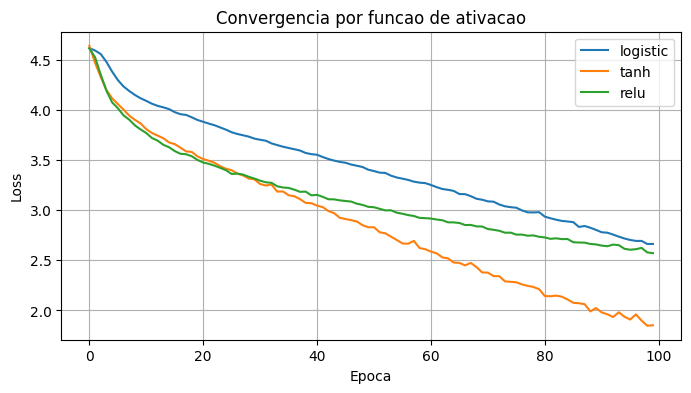

In [6]:
ARCH = (128, 64)
LR = 0.001

activation_models = {}
for act in ["logistic", "tanh", "relu"]:
    model, _ = run_experiment(
        run_name=f"activation_{act}",
        activation=act,
        hidden_layers=ARCH,
        learning_rate=LR,
    )
    activation_models[act] = model

df_act = pd.DataFrame(
    [r for r in RESULTS if r["run_name"].startswith("activation_")]
).set_index("activation")[["accuracy", "f1_score", "final_loss", "n_iter", "training_time"]]
print(df_act.round(4).to_string())

plt.figure(figsize=(8, 4))
for act, model in activation_models.items():
    plt.plot(model.loss_curve_, label=act)
plt.title("Convergencia por funcao de ativacao")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


### Respostas teoricas - Questao 5

*(Resultados reais: arquitetura (128,64), lr=0.001, 100 epocas, mesma seed.)*

| ativacao | accuracy | f1 | loss final | tempo |
|----------|----------|-----|-----------|-------|
| logistic | 0.139 | 0.125 | 2.663 | 46.7s |
| tanh | 0.144 | 0.137 | **1.852** | 41.9s |
| relu | **0.156** | **0.146** | 2.571 | 62.1s |

**1. Qual ativacao apresentou melhor convergencia?**
Depende da metrica: a **tanh** atingiu a **menor loss de treino (1.85)**, ou seja, a
descida mais profunda; ja a **ReLU** alcancou a **melhor accuracy de teste (0.156)**.
A `logistic` foi a mais limitada (maior loss e menor accuracy), coerente com sua tendencia
a saturar e produzir gradientes pequenos.

**2. Qual ativacao apresentou maior estabilidade?**
Com lr=0.001 as tres convergiram de forma suave, sem oscilacoes. As curvas de `tanh` e
`logistic` sao naturalmente estaveis por serem limitadas e diferenciaveis em todo o dominio;
a ReLU tambem foi estavel **neste learning rate** (importante: em lr=0.01 a propria ReLU
ficou presa - ver Questao 7, mostrando que sua estabilidade depende da taxa).

**3. Houve diferencas significativas no treinamento?**
Em accuracy as diferencas foram **modestas** (0.139 a 0.156). A diferenca mais marcante foi
na **loss final** (tanh bem menor) e no **tempo** (tanh foi a mais rapida; relu a mais lenta).

**4. Por que a ReLU e amplamente utilizada em Deep Learning?**
Porque e barata (`max(0, x)`), nao satura para entradas positivas (derivada 1), **evita o
vanishing gradient** e escala bem para redes profundas - aqui entregou a melhor accuracy de
teste. A ressalva e sua sensibilidade ao learning rate (com taxa alta pode "morrer" e parar
de aprender, como visto na Questao 7).


# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solução**:

[arch_(32,)] acc=0.0698 f1=0.0407 loss=3.9586 tempo=10.5s


[arch_(64,)] acc=0.1024 f1=0.0829 loss=3.5728 tempo=17.4s


[arch_(128, 64)] acc=0.1560 f1=0.1460 loss=2.5714 tempo=58.8s


[arch_(256, 128)] acc=0.1362 f1=0.1334 loss=1.1853 tempo=103.0s
               accuracy  f1_score  final_loss  training_time  n_iter
hidden_layers                                                       
(32,)            0.0698    0.0407      3.9586        10.5188     100
(64,)            0.1024    0.0829      3.5728        17.3765     100
(128, 64)        0.1560    0.1460      2.5714        58.8201     100
(256, 128)       0.1362    0.1334      1.1853       103.0217     100

Treino vs Teste (gap = overfitting):
       (32,): treino=0.079  teste=0.070  gap=0.009
       (64,): treino=0.154  teste=0.102  gap=0.052


   (128, 64): treino=0.352  teste=0.156  gap=0.196


  (256, 128): treino=0.712  teste=0.136  gap=0.576


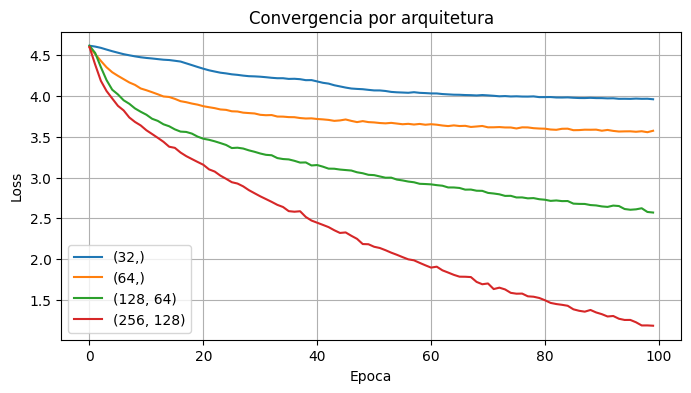

In [7]:
arch_models = {}
for arch in [(32,), (64,), (128, 64), (256, 128)]:
    model, _ = run_experiment(
        run_name=f"arch_{arch}",
        activation="relu",
        hidden_layers=arch,
        learning_rate=0.001,
    )
    arch_models[str(arch)] = model

df_arch = pd.DataFrame(
    [r for r in RESULTS if r["run_name"].startswith("arch_")]
).set_index("hidden_layers")[["accuracy", "f1_score", "final_loss", "training_time", "n_iter"]]
print(df_arch.round(4).to_string())

print("\nTreino vs Teste (gap = overfitting):")
for arch, model in arch_models.items():
    acc_train = model.score(X_train, y_train)
    acc_test = model.score(X_test, y_test)
    print(f"  {arch:>10}: treino={acc_train:.3f}  teste={acc_test:.3f}  gap={acc_train-acc_test:.3f}")

plt.figure(figsize=(8, 4))
for arch, model in arch_models.items():
    plt.plot(model.loss_curve_, label=arch)
plt.title("Convergencia por arquitetura")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


### Respostas teoricas - Questao 6

*(Resultados reais: ReLU, lr=0.001, 100 epocas.)*

| arquitetura | acc teste | loss final | tempo | gap treino-teste |
|-------------|-----------|-----------|-------|------------------|
| (32,) | 0.070 | 3.959 | 10.5s | 0.009 |
| (64,) | 0.102 | 3.573 | 17.4s | 0.052 |
| (128, 64) | **0.156** | 2.571 | 58.8s | 0.196 |
| (256, 128) | 0.136 | **1.185** | 103.0s | **0.576** |

**1. Redes maiores sempre melhoraram os resultados?**
**Nao.** A accuracy de teste subiu de (32,) ate (128,64), mas a **(256,128) PIOROU** no teste
(0.136 < 0.156), apesar de ter a menor loss de treino (1.19) e a maior accuracy de treino
(0.712). E o caso classico de **retorno decrescente + overfitting**: mais capacidade ajuda
ate certo ponto, depois atrapalha a generalizacao.

**2. Qual arquitetura apresentou melhor tradeoff?**
A **(128, 64)**: melhor accuracy de teste (0.156) com custo intermediario, bem melhor que a
(256,128) que custa quase o dobro do tempo e generaliza pior.

**3. Houve sinais de overfitting?**
**Sim, claros e crescentes com o tamanho da rede.** O gap treino-teste foi 0.009 -> 0.052
-> 0.196 -> 0.576. A (256,128) decorou o treino (acc treino 0.712) mas so acertou 0.136 no
teste - overfitting severo.

**4. Qual arquitetura apresentou maior custo computacional?**
A **(256, 128)**, com ~103s de treino (a primeira camada sozinha tem `3072 x 256 ~ 786 mil`
pesos), contra ~10s da (32,).


# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

[lr_0.1] acc=0.0100 f1=0.0002 loss=4.6341 tempo=32.2s


[lr_0.01] acc=0.0100 f1=0.0002 loss=4.6079 tempo=10.6s


[lr_0.001] acc=0.1560 f1=0.1460 loss=2.5714 tempo=58.8s
               accuracy  f1_score  final_loss  n_iter  training_time
learning_rate                                                       
0.100             0.010    0.0002      4.6341      56        32.2258
0.010             0.010    0.0002      4.6079      24        10.5711
0.001             0.156    0.1460      2.5714     100        58.8132


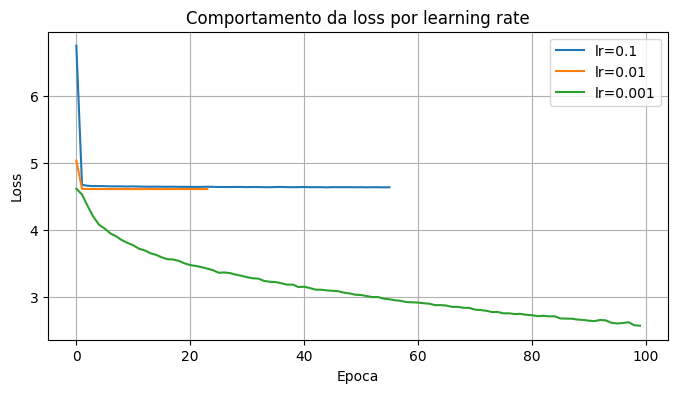

In [8]:
lr_models = {}
for lr in [0.1, 0.01, 0.001]:
    model, _ = run_experiment(
        run_name=f"lr_{lr}",
        activation="relu",
        hidden_layers=(128, 64),
        learning_rate=lr,
    )
    lr_models[lr] = model

df_lr = pd.DataFrame(
    [r for r in RESULTS if r["run_name"].startswith("lr_")]
).set_index("learning_rate")[["accuracy", "f1_score", "final_loss", "n_iter", "training_time"]]
print(df_lr.round(4).to_string())

plt.figure(figsize=(8, 4))
for lr, model in lr_models.items():
    plt.plot(model.loss_curve_, label=f"lr={lr}")
plt.title("Comportamento da loss por learning rate")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


### Respostas teoricas - Questao 7

*(Resultados reais: ReLU, arquitetura (128,64), 100 epocas.)*

| learning_rate | accuracy | loss final | n_iter | observacao |
|---------------|----------|-----------|--------|------------|
| 0.1 | 0.010 | 4.634 | 56 | nao aprendeu (acaso) |
| 0.01 | 0.010 | 4.608 | 24 | preso (loss ~= ln 100), parada precoce |
| 0.001 | **0.156** | **2.571** | 100 | unico que aprendeu |

**1. Qual learning rate apresentou melhor desempenho?**
O **learning_rate = 0.001**, de longe: accuracy 0.156 e loss 2.57, enquanto as taxas maiores
ficaram no acaso (0.01 de accuracy).

**2. Qual apresentou maior instabilidade?**
O **learning_rate = 0.1**: terminou com loss 4.634, **acima de ln(100) ~= 4.605** (o valor de
uma saida uniforme), indicando passos grandes demais que impedem a descida. A taxa 0.01
tambem falhou (loss ~= 4.608) e parou cedo (24 iteracoes) por nao melhorar.

**3. O que acontece quando o learning rate e muito alto?**
Os passos do gradiente sao grandes demais e **ultrapassam (overshoot) o minimo**, causando
oscilacao/divergencia. Com ReLU isso pode levar a neuronios "mortos" e a rede estagna em uma
saida quase uniforme (loss ~= ln(n_classes)), exatamente o observado em 0.1 e 0.01.

**4. O que acontece quando o learning rate e muito baixo?**
A convergencia fica **lenta**. Aqui 0.001 ainda estava melhorando ao atingir o limite de
100 epocas (n_iter=100, sem convergir) - ou seja, com mais epocas tenderia a melhorar. O
risco e demorar demais e/ou ficar preso em minimos locais.


# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

Resumo de todos os experimentos (ordenado por accuracy):
               run_name activation hidden_layers  learning_rate  accuracy  f1_score  final_loss  n_iter  training_time
0              baseline       relu     (128, 64)          0.001    0.1560    0.1460      2.5714     100        57.3728
1        arch_(128, 64)       relu     (128, 64)          0.001    0.1560    0.1460      2.5714     100        58.8201
2       activation_relu       relu     (128, 64)          0.001    0.1560    0.1460      2.5714     100        62.1166
3              lr_0.001       relu     (128, 64)          0.001    0.1560    0.1460      2.5714     100        58.8132
4       activation_tanh       tanh     (128, 64)          0.001    0.1436    0.1371      1.8519     100        41.9138
5   activation_logistic   logistic     (128, 64)          0.001    0.1386    0.1247      2.6632     100        46.6798
6       arch_(256, 128)       relu    (256, 128)          0.001    0.1362    0.1334      1.1853     100       

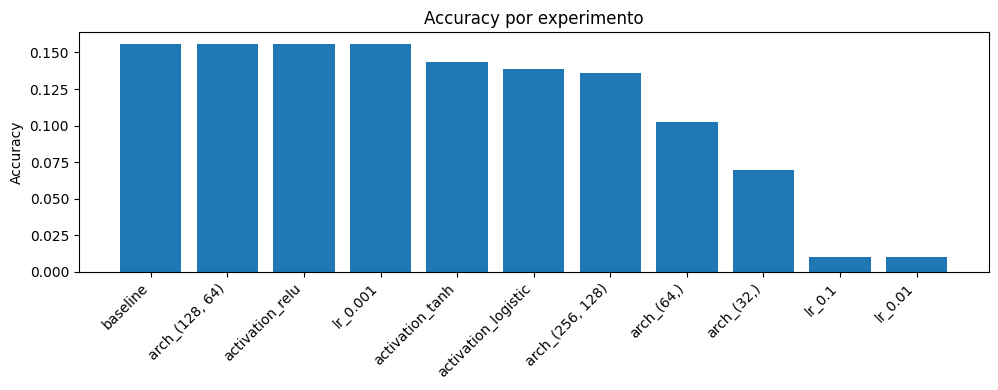

In [9]:
df_all = pd.DataFrame(RESULTS)
cols = ["run_name", "activation", "hidden_layers", "learning_rate",
        "accuracy", "f1_score", "final_loss", "n_iter", "training_time"]
df_all = df_all[cols].sort_values("accuracy", ascending=False).reset_index(drop=True)
print("Resumo de todos os experimentos (ordenado por accuracy):")
print(df_all.round(4).to_string())

best = df_all.iloc[0]
print("\n>>> Melhor configuracao:", best["run_name"],
      "| accuracy =", round(best["accuracy"], 4),
      "| f1 =", round(best["f1_score"], 4))

plt.figure(figsize=(10, 4))
plt.bar(df_all["run_name"], df_all["accuracy"])
plt.title("Accuracy por experimento")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Questao 8 - Discussao final

*(Discussao baseada nos resultados reais consolidados na celula anterior.)*

**Comportamento da loss.** Onde o treino funcionou (lr=0.001), a loss caiu de ~4.6 (acaso)
para 1.2-2.7, de forma suave. Onde o learning rate foi alto (0.01 e 0.1), a loss travou em
~4.6 = `ln(100)`, valor de uma saida uniforme: a rede nunca saiu do acaso.

**Impacto do learning rate.** Foi o fator **mais decisivo**. Apenas `0.001` aprendeu
(acc 0.156); `0.01` e `0.1` colapsaram para accuracy de acaso. Taxa alta + ReLU + Adam levou
a neuronios mortos e estagnacao. Taxa baixa e estavel, porem lenta (0.001 ainda melhorava ao
fim das 100 epocas).

**Impacto da arquitetura.** A capacidade ajudou de (32,) ate (128,64), mas a (256,128)
**piorou no teste** por overfitting (gap treino-teste de 0.576). Mais parametros nao
significam melhor generalizacao; (128,64) foi o melhor custo-beneficio.

**Impacto das funcoes de ativacao.** Em lr=0.001 as tres aprenderam: ReLU deu a melhor
accuracy de teste (0.156), tanh a menor loss de treino (1.85) e a maior velocidade,
logistic ficou atras. Mas a ReLU so funcionou em lr baixo - ela e a mais sensivel a taxa.

**Comportamento do treinamento.** Com subamostra e poucas epocas as accuracies sao baixas
(0.07-0.16), mas muito acima do acaso de 1%. O overfitting cresce com o tamanho da rede.

**Limitacoes da MLP.** O flatten **destroi a estrutura espacial** (vizinhanca de pixels) e
nao ha invariancia a translacao. Por ser totalmente conectada, gera um numero enorme de
parametros (so a 1a camada de (256,128) tem ~786 mil pesos), encarecendo o treino e
favorecendo overfitting. Para visao, CNNs (convolucoes + compartilhamento de pesos) sao
muito superiores.

**Relacao entre backpropagation e aprendizado.** O backpropagation calcula, via regra da
cadeia, o gradiente da loss em relacao a cada peso, propagando o erro da saida para as
camadas anteriores. Esses gradientes alimentam o otimizador (Adam), que ajusta os pesos para
reduzir a loss. Quando o learning rate quebra esse processo (passos grandes demais), o
backpropagation nao consegue reduzir a loss e o aprendizado nao acontece - exatamente o que
vimos em lr=0.01 e 0.1.

---

**1. Qual configuracao apresentou melhor resultado final?**
**ReLU + arquitetura (128, 64) + learning_rate = 0.001**, com accuracy ~= 0.156 e f1 ~= 0.146
(o melhor entre os 11 experimentos).

**2. Quais foram as principais dificuldades observadas?**
(i) Sensibilidade extrema ao learning rate - taxas de 0.01 e 0.1 fizeram a rede colapsar
para o acaso (loss = ln 100); (ii) overfitting forte nas redes maiores; (iii) accuracy
absoluta baixa, inerente a uma MLP em imagens; (iv) alto custo computacional pelo grande
numero de parametros; (v) convergencia ainda incompleta em 100 epocas com lr=0.001.

**3. Por que MLPs possuem limitacoes para imagens?**
Porque ignoram a estrutura espacial (o flatten destroi a vizinhanca dos pixels), nao tem
invariancia a translacao e exigem um numero proibitivo de parametros por nao compartilharem
pesos - diferente das CNNs.

**4. Como o backpropagation contribui para o aprendizado da rede?**
Ele fornece o gradiente da loss para cada parametro, permitindo que o otimizador atualize os
pesos minimizando o erro iterativamente. Sem ele nao haveria como saber em que direcao
ajustar os milhares de pesos das camadas ocultas; e o motor do aprendizado.
